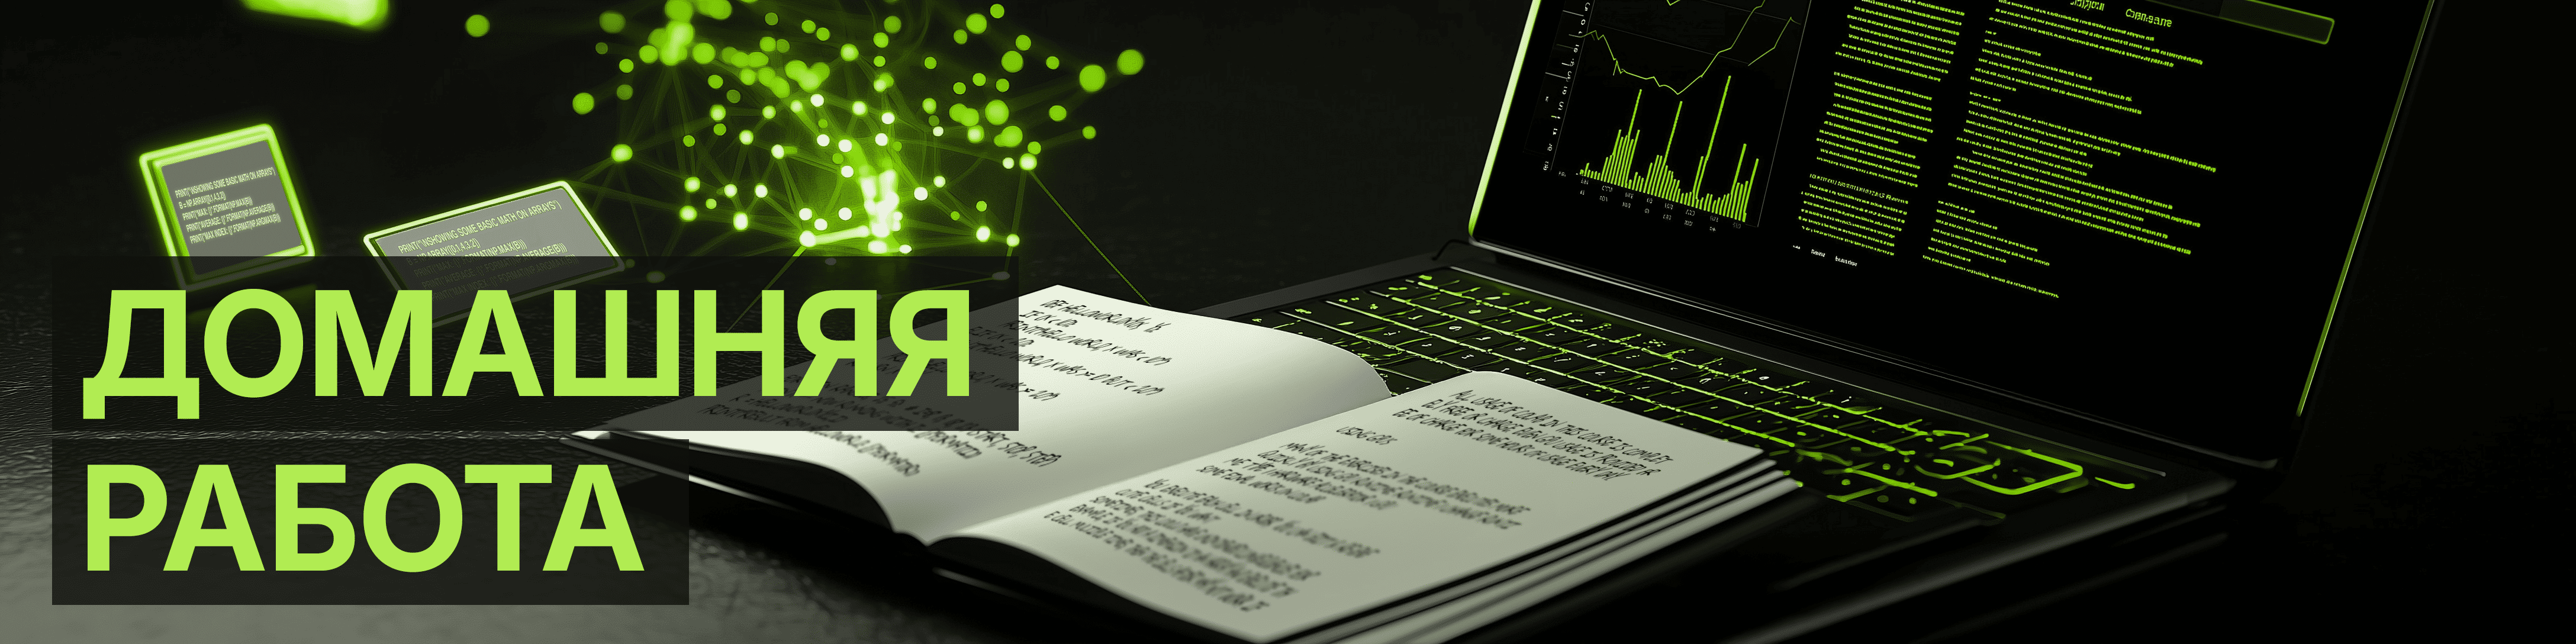

**Навигация по уроку**
1. [Автокодировщик GAN. Генеративно-состязательные сети](https://colab.research.google.com/drive/15hs_BV9OGUuaTmVetqYaAUf8zpDgxz3_)
2. [Сверточные GAN. Генерация фейковых лиц](https://colab.research.google.com/drive/1mCDkjVfw4-ZWysmat7LH-xAmssZj6ANU)
3. [CyrcleGAN. Создаем картины в стиле Моне](https://colab.research.google.com/drive/1SKpzFYFsiU53E1BpRS4waNzQ_mVk-XMz)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Ваша задача, используя датасет MNIST (из набора датасетов Tensorflow) научить GAN генерировать цифры.

2. Добейтесь хорошего качества генерации.

**Задание 2. На 4 балла:**

1. Ваша задача, используя датасет MNIST Fashion (из набора датасетов Tensorflow) научить GAN генерировать образцы одежды, соответственно.

2. Добейтесь хорошего качества генерации.

**Задание 3. На 5 баллов:**

1. Ваша задача, провести небольшое научное исследование, используя датасет MNIST Fashion (из набора датасетов Tensorflow) сравнить 2 разных модели DCGAN.

2. Необходимо, используя 2 разных генератора: классического GAN (на рис. 2. второй части урока) и улучшенного (из примера по генерации фейковых лиц), научить GAN генерировать образцы одежды.

2. Добейтесь хорошего качества генерации. Сравнить обе модели, сделайте выводы.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
import matplotlib.pyplot as plt
import os
import time


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

BUFFER_SIZE = 60000
BATCH_SIZE = 128
NOISE_DIM = 100
EPOCHS = 30
IMAGE_SIZE = 64

In [ ]:
# Загрузка датасета MNIST Fashion
(train_images, train_labels), (_, _) = tf.keras.datasets.fashion_mnist.load_data()

def preprocess_images(images):
    images = images.reshape(images.shape[0], 28, 28, 1).astype('float32')
    images = tf.image.resize(images, [IMAGE_SIZE, IMAGE_SIZE])
    images = (images - 127.5) / 127.5
    return images

train_images = preprocess_images(train_images)

# Создание tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

print(f"Форма обучающих изображений после предобработки: {train_images.shape}")
print(f"Диапазон значений пикселей: [{np.min(train_images)}, {np.max(train_images)}]")


In [ ]:
cross_entropy = losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [ ]:
def make_classic_generator_model():
    model = models.Sequential()
    model.add(layers.Dense(4 * 4 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((4, 4, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model


In [ ]:
def make_discriminator_model():
    model = models.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[IMAGE_SIZE, IMAGE_SIZE, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

generator1 = make_classic_generator_model()
discriminator1 = make_discriminator_model()

generator_optimizer1 = optimizers.Adam(1e-4)
discriminator_optimizer1 = optimizers.Adam(1e-4)

dummy_noise = tf.random.normal([1, NOISE_DIM])
dummy_image = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 1])

_ = generator1(dummy_noise)
_ = discriminator1(dummy_image)

generator_optimizer1.apply_gradients([(tf.zeros_like(var), var) for var in generator1.trainable_variables])
discriminator_optimizer1.apply_gradients([(tf.zeros_like(var), var) for var in discriminator1.trainable_variables])

In [ ]:
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, NOISE_DIM])

def generate_and_save_images(model, epoch, test_input, model_name):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow((predictions[i, :, :, 0] * 127.5 + 127.5).numpy().astype(np.uint8), cmap='gray')
        plt.axis('off')
    plt.savefig(f'./{model_name}_image_at_epoch_{epoch:04d}.png')
    plt.close(fig)

@tf.function
def train_step(images, generator, discriminator, gen_optimizer, disc_optimizer):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

def train_gan_model(dataset, generator, discriminator, gen_optimizer, disc_optimizer, epochs, model_name):
    history_gen_loss = []
    history_disc_loss = []

    print(f"\n--- Начало обучения модели: {model_name} ---")

    output_dir = f'./{model_name}_generated_images'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for epoch in range(epochs):
        start = time.time()

        gen_loss_epoch = []
        disc_loss_epoch = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch, generator, discriminator, gen_optimizer, disc_optimizer)
            gen_loss_epoch.append(g_loss.numpy())
            disc_loss_epoch.append(d_loss.numpy())

        avg_gen_loss = np.mean(gen_loss_epoch)
        avg_disc_loss = np.mean(disc_loss_epoch)

        history_gen_loss.append(avg_gen_loss)
        history_disc_loss.append(avg_disc_loss)

        print(f'Эпоха {epoch+1:04d}, Время {time.time()-start:.2f} сек')
        print(f'  Gen Loss: {avg_gen_loss:.4f}, Disc Loss: {avg_disc_loss:.4f}')

        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
            generate_and_save_images(generator, epoch + 1, seed, f'{output_dir}/{model_name}')

    print(f"--- Обучение модели {model_name} завершено ---")
    return history_gen_loss, history_disc_loss


history1_gen_loss, history1_disc_loss = train_gan_model(
    train_dataset, generator1, discriminator1,
    generator_optimizer1, discriminator_optimizer1,
    EPOCHS, "Classic_GAN"
)

np.save('history1_gen_loss.npy', history1_gen_loss)
np.save('history1_disc_loss.npy', history1_disc_loss)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Форма обучающих изображений после предобработки: (60000, 64, 64, 1)
Диапазон значений пикселей: [-1.0, 1.0]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Начало обучения модели: Classic_GAN ---
Эпоха 0001, Время 142.55 сек
  Gen Loss: 4.3881, Disc Loss: 0.2872
Эпоха 0002, Время 81.90 сек
  Gen Loss: 3.2446, Disc Loss: 0.4168
Эпоха 0003, Время 77.01 сек
  Gen Loss: 3.6664, Disc Loss: 0.4165
Эпоха 0004, Время 81.90 сек
  Gen Loss: 4.3839, Disc Loss: 0.2694
Эпоха 0005, Время 76.85 сек
  Gen Loss: 4.3792, Disc Loss: 0.2661
Эпоха 0006, Время 76.82 сек
  Gen Loss: 4.4266, Disc Loss: 0.2943
Эпоха 0007, Время 76.59 сек
  Gen Loss: 4.2289, Disc Loss: 0.2758
Эпоха 0008, Время 81.90 сек
  Gen Loss: 4.5161, Disc Loss: 0.2438
Эпоха 0009, Время 76.84 сек
  Gen Loss: 4.4207, Disc Loss: 0.2499
Эпоха 0010, Время 76.37 сек
  Gen Loss: 4.5972, Disc Loss: 0.2269
Эпоха 0011, Время 76.68 сек
  Gen Loss: 4.8156, Disc Loss: 0.2247
Эпоха 0012, Время 76.56 сек
  Gen Loss: 5.4028, Disc Loss: 0.1711
Эпоха 0013, Время 76.30 сек
  Gen Loss: 5.3223, Disc Loss: 0.1398
Эпоха 0014, Время 76.36 сек
  Gen Loss: 5.7942, Disc Loss: 0.1627
Эпоха 0015, Время 76.28 сек
  


--- Демонстрация генерации Classic GAN (сразу после обучения) ---


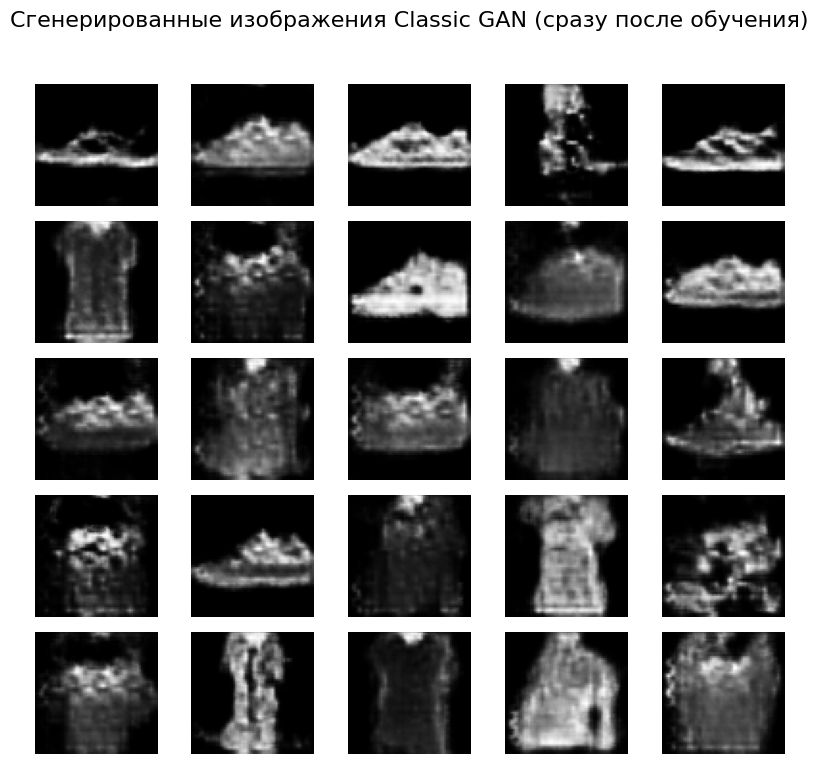

In [ ]:

print("\n--- Демонстрация генерации Classic GAN (сразу после обучения) ---")
num_demo_images = 25
demo_noise = tf.random.normal([num_demo_images, NOISE_DIM])
predictions = generator1(demo_noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(predictions.shape[0]):
    plt.subplot(5, 5, i + 1)
    plt.imshow((predictions[i, :, :, 0] * 127.5 + 127.5).numpy().astype(np.uint8), cmap='gray')
    plt.axis('off')
plt.suptitle('Сгенерированные изображения Classic GAN (сразу после обучения)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [ ]:
NOISE_DIM = 100
IMAGE_SIZE = 64
BATCH_SIZE = 128
EPOCHS = 30

In [ ]:
try:
    history1_gen_loss = np.load('history1_gen_loss.npy').tolist()
    history1_disc_loss = np.load('history1_disc_loss.npy').tolist()
    print("Метрики Classic_GAN успешно загружены.")
except FileNotFoundError:
    print("Метрики Classic_GAN не найдены.")

    history1_gen_loss = []
    history1_disc_loss = []

In [ ]:
def make_improved_generator_model():
    model = models.Sequential()
    model.add(layers.Dense(4 * 4 * 1024, input_shape=(NOISE_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((4, 4, 1024)))

    model.add(layers.Conv2DTranspose(512, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', activation='tanh'))
    return model

In [ ]:
try:
    make_discriminator_model # Проверяем, определена ли функция
except NameError:
    def make_discriminator_model():
        model = models.Sequential()
        model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[IMAGE_SIZE, IMAGE_SIZE, 1]))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(0.3))

        model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(0.3))

        model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(0.3))

        model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(0.3))

        model.add(layers.Flatten())
        model.add(layers.Dense(1))
        return model

Метрики Classic_GAN успешно загружены.

--- Начало обучения модели: Improved_GAN ---
Эпоха 0001, Время 183.29 сек
  Gen Loss: 3.3350, Disc Loss: 0.5248
Эпоха 0002, Время 178.04 сек
  Gen Loss: 2.6414, Disc Loss: 0.6397
Эпоха 0003, Время 178.14 сек
  Gen Loss: 3.1333, Disc Loss: 0.5450
Эпоха 0004, Время 178.16 сек
  Gen Loss: 2.9531, Disc Loss: 0.5885
Эпоха 0005, Время 178.10 сек
  Gen Loss: 3.4925, Disc Loss: 0.4533
Эпоха 0006, Время 177.74 сек
  Gen Loss: 3.9876, Disc Loss: 0.3095
Эпоха 0007, Время 201.90 сек
  Gen Loss: 3.7555, Disc Loss: 0.3286
Эпоха 0008, Время 179.16 сек
  Gen Loss: 3.6391, Disc Loss: 0.3610
Эпоха 0009, Время 178.14 сек
  Gen Loss: 3.5069, Disc Loss: 0.3847
Эпоха 0010, Время 178.21 сек
  Gen Loss: 3.3642, Disc Loss: 0.3683
Эпоха 0011, Время 178.20 сек
  Gen Loss: 3.6537, Disc Loss: 0.3508
Эпоха 0012, Время 178.27 сек
  Gen Loss: 3.8520, Disc Loss: 0.3122
Эпоха 0013, Время 178.07 сек
  Gen Loss: 3.9593, Disc Loss: 0.2674
Эпоха 0014, Время 177.66 сек
  Gen Loss: 4.4

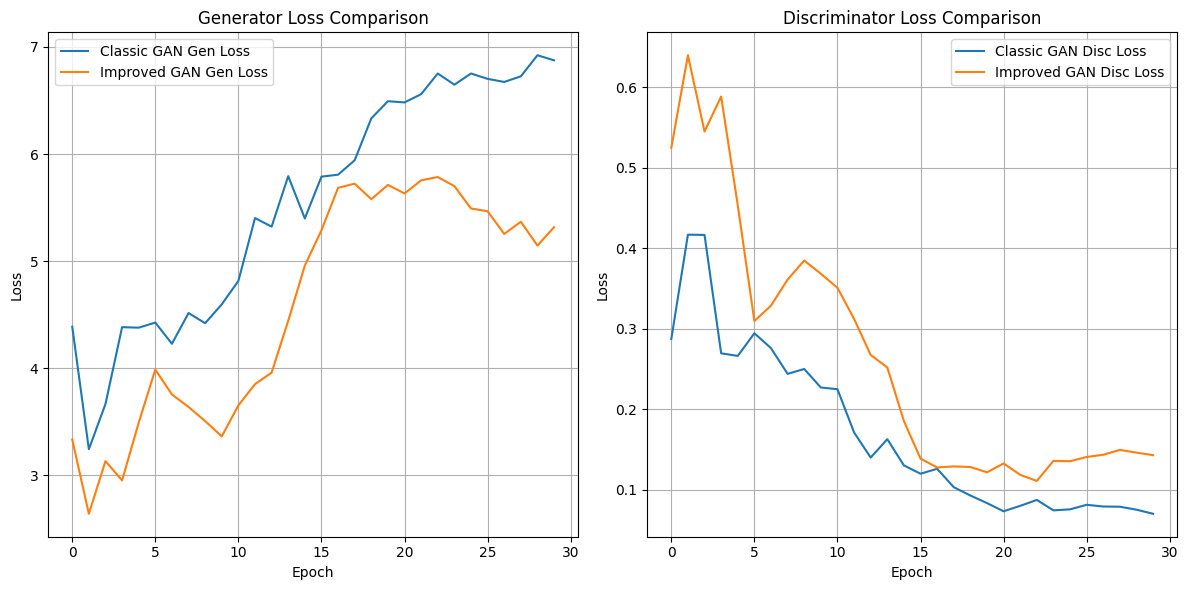

In [ ]:
generator2 = make_improved_generator_model()
discriminator2 = make_discriminator_model() # Общий дискриминатор

generator_optimizer2 = optimizers.Adam(1e-4)
discriminator_optimizer2 = optimizers.Adam(1e-4)

dummy_noise = tf.random.normal([1, NOISE_DIM])
dummy_image = tf.random.normal([1, IMAGE_SIZE, IMAGE_SIZE, 1])

_ = generator2(dummy_noise)
_ = discriminator2(dummy_image)

generator_optimizer2.apply_gradients([(tf.zeros_like(var), var) for var in generator2.trainable_variables])
discriminator_optimizer2.apply_gradients([(tf.zeros_like(var), var) for var in discriminator2.trainable_variables])

try:
    train_gan_model
except NameError:

    cross_entropy = losses.BinaryCrossentropy(from_logits=True)
    def discriminator_loss(real_output, fake_output):
        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        total_loss = real_loss + fake_loss
        return total_loss
    def generator_loss(fake_output):
        return cross_entropy(tf.ones_like(fake_output), fake_output)

    num_examples_to_generate = 16
    seed = tf.random.normal([num_examples_to_generate, NOISE_DIM])

    def generate_and_save_images(model, epoch, test_input, model_name):
        predictions = model(test_input, training=False)
        fig = plt.figure(figsize=(4, 4))
        for i in range(predictions.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow((predictions[i, :, :, 0] * 127.5 + 127.5).numpy().astype(np.uint8), cmap='gray')
            plt.axis('off')
        plt.savefig(f'./{model_name}_image_at_epoch_{epoch:04d}.png')
        plt.close(fig)

    @tf.function
    def train_step(images, generator, discriminator, gen_optimizer, disc_optimizer):
        noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = generator(noise, training=True)
            real_output = discriminator(images, training=True)
            fake_output = discriminator(generated_images, training=True)
            gen_loss = generator_loss(fake_output)
            disc_loss = discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

        gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
        disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
        return gen_loss, disc_loss

    def train_gan_model(dataset, generator, discriminator, gen_optimizer, disc_optimizer, epochs, model_name):
        history_gen_loss = []
        history_disc_loss = []
        print(f"\n--- Начало обучения модели: {model_name} ---")
        output_dir = f'./{model_name}_generated_images'
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        for epoch in range(epochs):
            start = time.time()
            gen_loss_epoch = []
            disc_loss_epoch = []
            for image_batch in dataset:
                g_loss, d_loss = train_step(image_batch, generator, discriminator, gen_optimizer, disc_optimizer)
                gen_loss_epoch.append(g_loss.numpy())
                disc_loss_epoch.append(d_loss.numpy())
            avg_gen_loss = np.mean(gen_loss_epoch)
            avg_disc_loss = np.mean(disc_loss_epoch)
            history_gen_loss.append(avg_gen_loss)
            history_disc_loss.append(avg_disc_loss)
            print(f'Эпоха {epoch+1:04d}, Время {time.time()-start:.2f} сек')
            print(f'  Gen Loss: {avg_gen_loss:.4f}, Disc Loss: {avg_disc_loss:.4f}')
            if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
                generate_and_save_images(generator, epoch + 1, seed, f'{output_dir}/{model_name}')
        print(f"--- Обучение модели {model_name} завершено ---")
        return history_gen_loss, history_disc_loss


history2_gen_loss, history2_disc_loss = train_gan_model(
    train_dataset, generator2, discriminator2,
    generator_optimizer2, discriminator_optimizer2,
    EPOCHS, "Improved_GAN"
)


print("\n--- Сравнение моделей и выводы ---")

# Визуализация графиков потерь
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history1_gen_loss, label='Classic GAN Gen Loss')
plt.plot(history2_gen_loss, label='Improved GAN Gen Loss')
plt.title('Generator Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history1_disc_loss, label='Classic GAN Disc Loss')
plt.plot(history2_disc_loss, label='Improved GAN Disc Loss')
plt.title('Discriminator Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Демонстрация генерации Improved GAN (сразу после обучения) ---


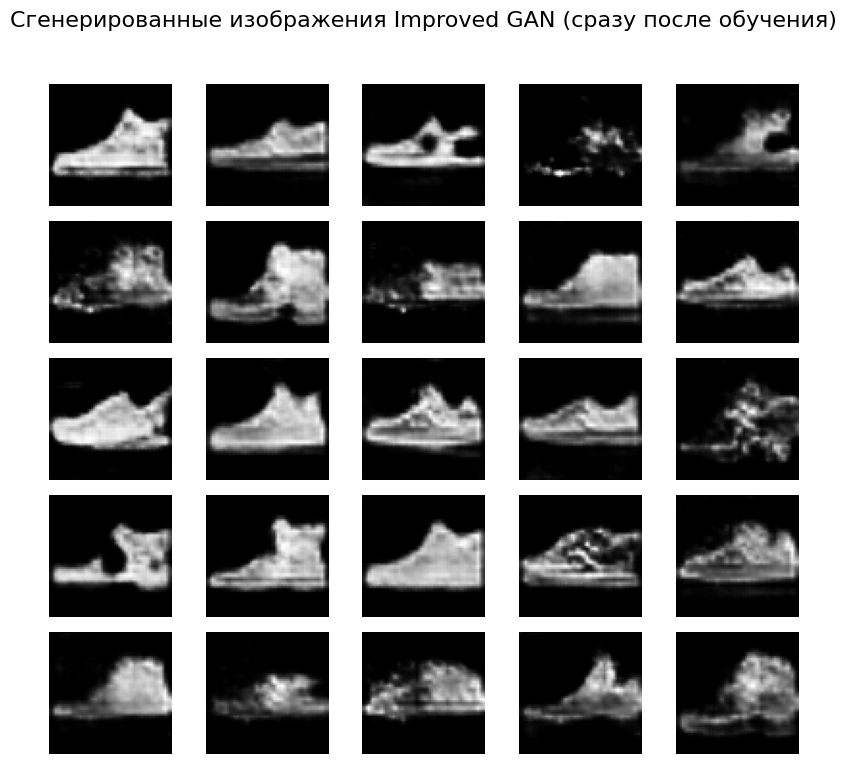

In [ ]:
print("\n--- Демонстрация генерации Improved GAN (сразу после обучения) ---")
num_demo_images = 25
demo_noise = tf.random.normal([num_demo_images, NOISE_DIM])
predictions = generator2(demo_noise, training=False)

plt.figure(figsize=(8, 8))
for i in range(predictions.shape[0]):
    plt.subplot(5, 5, i + 1)
    plt.imshow((predictions[i, :, :, 0] * 127.5 + 127.5).numpy().astype(np.uint8), cmap='gray')
    plt.axis('off')
plt.suptitle('Сгенерированные изображения Improved GAN (сразу после обучения)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()


Основываясь на визуальном анализе, "Продвинутый GAN" демонстрирует значительно лучшие результаты генерации изображений по сравнению с "Классическим GAN".

Изображения, сгенерированные продвинутой моделью, более четкие, имеют лучшую детализацию и в целом выглядят более реалистично. Это указывает на то, что продвинутая архитектура (вероятно, с улучшенным генератором, как в вашем коде Improved GAN, где используется больше слоев и фильтров) лучше справляется с задачей обучения распределения данных и генерации высококачественных образцов.
Классический GAN, напротив, производит очень абстрактные и размытые изображения, что может быть связано с более простой архитектурой, недостаточным количеством эпох обучения или проблемами сходимости.